# Triangles

## Contents
1. [Basic Terms](#1.-Basic-Terms)
2. [Classification of Triangles](#2.-Classification-of-Triangles)
3. [Angle Sum Property and Exterior Angle Theorem](#3.-Angle-Sum-Property-and-Exterior-Angle-Theorem)
4. [Triangle Inequality and Side–Angle Relations](#4.-Triangle-Inequality-and-Side–Angle-Relations)
5. [Important Lines in a Triangle](#5.-Important-Lines-in-a-Triangle)
6. [Congruence of Triangles](#6.-Congruence-of-Triangles)
7. [Isosceles and Equilateral Triangles](#7.-Isosceles-and-Equilateral-Triangles)
8. [Midpoint Theorem](#8.-Midpoint-Theorem)
9. [Similarity of Triangles](#9.-Similarity-of-Triangles)
10. [Pythagoras Theorem](#10.-Pythagoras-Theorem)
11. [Special Right Triangles](#11.-Special-Right-Triangles)
12. [Area and Perimeter](#12.-Area-and-Perimeter)
13. [Centres of a Triangle](#13.-Centres-of-a-Triangle)
14. [Important Theorems (Angle Bisector, Apollonius, Sine and Cosine Rules)](#14.-Important-Theorems)
15. [Triangles in Coordinate Geometry](#15.-Triangles-in-Coordinate-Geometry)
16. [Common Mistakes](#16.-Common-Mistakes)
17. [Formula Sheet](#17.-Formula-Sheet)
18. [Practice Problems (with Answers)](#18.-Practice-Problems-(with-Answers))

**Notation used throughout:** for triangle $ABC$, the side opposite vertex $A$ is $a = BC$, opposite $B$ is $b = CA$, opposite $C$ is $c = AB$. The angles at the vertices are $\angle A, \angle B, \angle C$. The semi-perimeter is $s = \dfrac{a + b + c}{2}$.

In [1]:
# Helper toolkit used by the code cells in this notebook
import math
import numpy as np
import matplotlib.pyplot as plt

def dist(P, Q):
    return math.hypot(P[0] - Q[0], P[1] - Q[1])

def side_lengths(A, B, C):
    """Return (a, b, c): the sides opposite A, B, C."""
    return dist(B, C), dist(C, A), dist(A, B)

def angles_from_sides(a, b, c):
    """Angles A, B, C in degrees, using the cosine rule."""
    A = math.degrees(math.acos((b*b + c*c - a*a) / (2*b*c)))
    B = math.degrees(math.acos((c*c + a*a - b*b) / (2*c*a)))
    return A, B, 180 - A - B

def is_triangle(a, b, c):
    return a + b > c and b + c > a and c + a > b

def classify(a, b, c, tol=1e-9):
    x, y, z = sorted([a, b, c])
    if math.isclose(x, z):
        by_sides = "equilateral"
    elif math.isclose(x, y) or math.isclose(y, z):
        by_sides = "isosceles"
    else:
        by_sides = "scalene"
    diff = x*x + y*y - z*z
    by_angles = "right" if abs(diff) < tol else ("acute" if diff > 0 else "obtuse")
    return by_sides, by_angles

def heron(a, b, c):
    s = (a + b + c) / 2
    return math.sqrt(s * (s - a) * (s - b) * (s - c))

def shoelace(A, B, C):
    return abs(A[0]*(B[1] - C[1]) + B[0]*(C[1] - A[1]) + C[0]*(A[1] - B[1])) / 2

def centres(A, B, C):
    """Return centroid G, incentre I, circumcentre O, orthocentre H."""
    A, B, C = map(np.array, (A, B, C))
    a, b, c = side_lengths(A, B, C)
    G = (A + B + C) / 3
    I = (a*A + b*B + c*C) / (a + b + c)
    d = 2 * (A[0]*(B[1] - C[1]) + B[0]*(C[1] - A[1]) + C[0]*(A[1] - B[1]))
    ox = ((A@A)*(B[1] - C[1]) + (B@B)*(C[1] - A[1]) + (C@C)*(A[1] - B[1])) / d
    oy = ((A@A)*(C[0] - B[0]) + (B@B)*(A[0] - C[0]) + (C@C)*(B[0] - A[0])) / d
    O = np.array([ox, oy])
    H = 3*G - 2*O          # Euler line relation: H, G, O collinear with HG = 2 GO
    return G, I, O, H

def draw_triangle(ax, A, B, C, labels="ABC", **kw):
    pts = np.array([A, B, C, A])
    ax.plot(pts[:, 0], pts[:, 1], **({"color": "C0"} | kw))
    for P, name in zip((A, B, C), labels):
        ax.annotate(name, P, textcoords="offset points", xytext=(4, 4))
    ax.set_aspect("equal")

print("Toolkit loaded.")

Toolkit loaded.


## 1. Basic Terms

A **triangle** is a closed figure formed by three line segments joining three **non-collinear** points.

| Term | Meaning |
|------|---------|
| Vertices | The three points $A, B, C$ |
| Sides | The segments $AB, BC, CA$ |
| Interior angles | $\angle A = \angle BAC$, $\angle B = \angle ABC$, $\angle C = \angle BCA$ |
| Exterior angle | Angle between one side and the extension of an adjacent side |
| Interior opposite angles | For an exterior angle at $C$, the two interior angles at $A$ and $B$ |
| Perimeter | $a + b + c$ |
| Semi-perimeter | $s = \frac{a + b + c}{2}$ |

A triangle has **6 elements** (3 sides + 3 angles). Knowing the right 3 of them (with at least one side) fixes the triangle — this is the idea behind congruence (Section 6).

If the three points are collinear, the "triangle" has zero area and is called **degenerate**.

## 2. Classification of Triangles

### By sides

| Type | Property | Angle consequence |
|------|----------|-------------------|
| **Scalene** | All sides different | All angles different |
| **Isosceles** | At least two sides equal | Angles opposite equal sides are equal |
| **Equilateral** | All three sides equal | All angles $= 60^\circ$ |

### By angles

| Type | Property |
|------|----------|
| **Acute** | All angles $< 90^\circ$ |
| **Right** | One angle $= 90^\circ$ (side opposite it is the **hypotenuse**, the longest side) |
| **Obtuse** | One angle $> 90^\circ$ |

A triangle can have **at most one** right or obtuse angle (otherwise the angle sum would exceed $180^\circ$).

### Classifying from side lengths alone

Let $c$ be the **longest** side. Then

| Condition | Triangle is |
|-----------|-------------|
| $a^2 + b^2 > c^2$ | acute |
| $a^2 + b^2 = c^2$ | right |
| $a^2 + b^2 < c^2$ | obtuse |

**Example.** Sides 7, 8, 12: $49 + 64 = 113 < 144$ → obtuse scalene.

In [2]:
for sides in [(3, 4, 5), (5, 5, 5), (5, 5, 8), (7, 8, 12), (4, 5, 6), (1, 1, math.sqrt(2))]:
    a, b, c = sides
    by_sides, by_angles = classify(*sides)
    angs = ", ".join(f"{t:.1f}°" for t in angles_from_sides(*sides))
    print(f"{str(tuple(round(s, 3) for s in sides)):<20} {by_angles:>6} {by_sides:<12} angles: {angs}")

(3, 4, 5)             right scalene      angles: 36.9°, 53.1°, 90.0°
(5, 5, 5)             acute equilateral  angles: 60.0°, 60.0°, 60.0°
(5, 5, 8)            obtuse isosceles    angles: 36.9°, 36.9°, 106.3°
(7, 8, 12)           obtuse scalene      angles: 34.1°, 39.8°, 106.1°
(4, 5, 6)             acute scalene      angles: 41.4°, 55.8°, 82.8°
(1, 1, 1.414)         right isosceles    angles: 45.0°, 45.0°, 90.0°


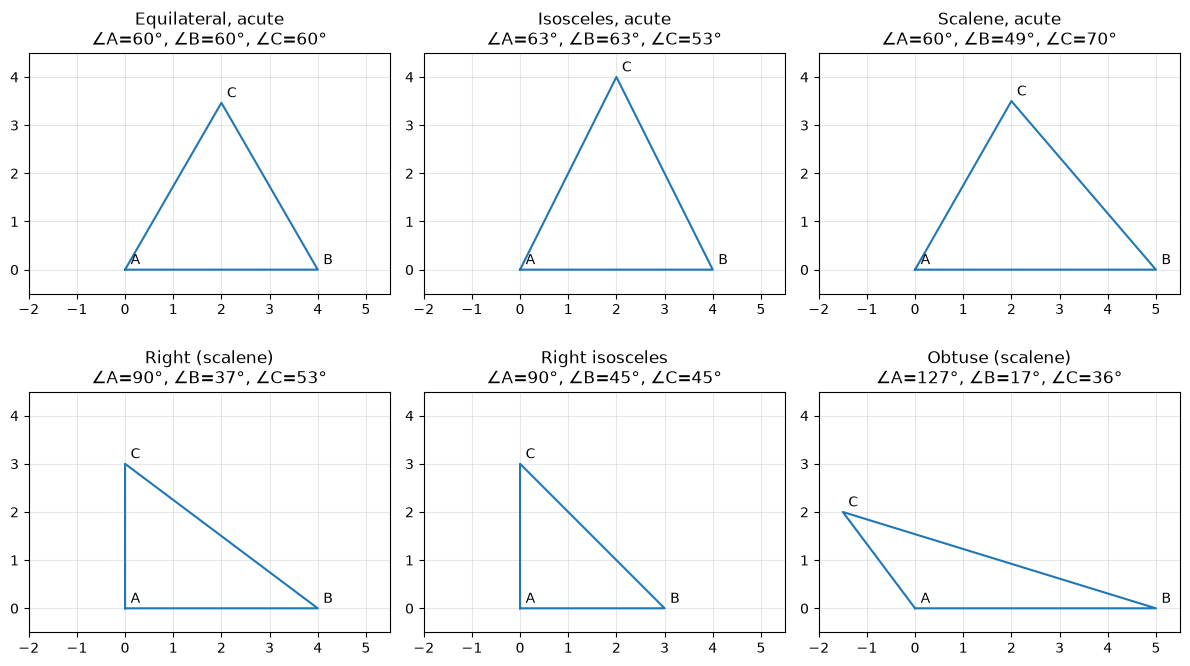

In [3]:
examples = [
    ("Equilateral, acute", (0, 0), (4, 0), (2, 2*math.sqrt(3))),
    ("Isosceles, acute", (0, 0), (4, 0), (2, 4)),
    ("Scalene, acute", (0, 0), (5, 0), (2, 3.5)),
    ("Right (scalene)", (0, 0), (4, 0), (0, 3)),
    ("Right isosceles", (0, 0), (3, 0), (0, 3)),
    ("Obtuse (scalene)", (0, 0), (5, 0), (-1.5, 2)),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (title, A, B, C) in zip(axes.flat, examples):
    draw_triangle(ax, A, B, C)
    angs = angles_from_sides(*side_lengths(A, B, C))
    ax.set_title(f"{title}\n∠A={angs[0]:.0f}°, ∠B={angs[1]:.0f}°, ∠C={angs[2]:.0f}°")
    ax.set_xlim(-2, 5.5); ax.set_ylim(-0.5, 4.5); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Angle Sum Property and Exterior Angle Theorem

### Angle Sum Property

$$\boxed{\angle A + \angle B + \angle C = 180^\circ}$$

**Proof.** Through $A$ draw line $PQ \parallel BC$.
- $\angle PAB = \angle B$ (alternate interior angles, $PQ \parallel BC$, transversal $AB$)
- $\angle QAC = \angle C$ (alternate interior angles, transversal $AC$)
- $\angle PAB + \angle A + \angle QAC = 180^\circ$ (angles on a straight line)
- Hence $\angle B + \angle A + \angle C = 180^\circ$. ∎

### Exterior Angle Theorem

If side $BC$ is extended to $D$, then

$$\boxed{\angle ACD = \angle A + \angle B}$$

The exterior angle equals the **sum of the two interior opposite angles**.

**Proof.** $\angle ACD + \angle C = 180^\circ$ (linear pair) and $\angle A + \angle B + \angle C = 180^\circ$. Subtract. ∎

**Consequences**
- An exterior angle is **greater than each** interior opposite angle.
- The sum of the three exterior angles (one at each vertex) is $360^\circ$.
- In a right triangle the two acute angles are **complementary** (sum to $90^\circ$).

**Example.** The angles of a triangle are in the ratio $2 : 3 : 4$. Then $2x + 3x + 4x = 180^\circ \Rightarrow x = 20^\circ$, so the angles are $40^\circ, 60^\circ, 80^\circ$.

**Example.** An exterior angle is $110^\circ$ and one interior opposite angle is $45^\circ$. The other interior opposite angle is $110^\circ - 45^\circ = 65^\circ$, and the adjacent interior angle is $70^\circ$.

In [4]:
# Numerical check: random triangles always have angle sum 180°
rng = np.random.default_rng(0)
for _ in range(5):
    A, B, C = rng.uniform(-10, 10, size=(3, 2))
    angs = angles_from_sides(*side_lengths(A, B, C))
    # compute C independently (not as 180 - A - B) to make the check meaningful
    a, b, c = side_lengths(A, B, C)
    angC = math.degrees(math.acos((a*a + b*b - c*c) / (2*a*b)))
    print(f"A={angs[0]:6.2f}°  B={angs[1]:6.2f}°  C={angC:6.2f}°   sum = {angs[0] + angs[1] + angC:.6f}°")

A=128.36°  B= 26.23°  C= 25.42°   sum = 180.000000°
A=179.02°  B=  0.76°  C=  0.22°   sum = 180.000000°
A= 42.61°  B=117.99°  C= 19.40°   sum = 180.000000°
A=163.47°  B=  8.56°  C=  7.96°   sum = 180.000000°
A= 17.86°  B= 10.74°  C=151.40°   sum = 180.000000°


## 4. Triangle Inequality and Side–Angle Relations

### Triangle Inequality

The sum of any two sides is **greater** than the third:

$$a + b > c, \qquad b + c > a, \qquad c + a > b$$

Equivalently, each side lies strictly between the difference and the sum of the other two:

$$|b - c| < a < b + c$$

**Quick test:** it is enough to check that the **two smaller sides add up to more than the largest**.

**Example.** Can 4, 5, 10 form a triangle? $4 + 5 = 9 < 10$ → **No**.

**Example.** Two sides are 5 and 9. The third side $x$ satisfies $9 - 5 < x < 9 + 5$, i.e. $4 < x < 14$.

### Side–Angle Relations

- In any triangle, the **larger side is opposite the larger angle**, and conversely.
- The **smallest side is opposite the smallest angle**.
- In a right triangle the hypotenuse is the longest side; in an obtuse triangle the side opposite the obtuse angle is the longest.
- Of all segments from a point to a line, the **perpendicular is the shortest**.

**Example.** In $\triangle ABC$, $\angle A = 50^\circ$, $\angle B = 60^\circ$, so $\angle C = 70^\circ$. Then $c > b > a$, i.e. $AB > CA > BC$.

In [5]:
for sides in [(4, 5, 10), (3, 4, 7), (5, 9, 6), (2, 2, 3.99), (1, 2, 3)]:
    print(sides, "->", "valid triangle" if is_triangle(*sides) else "NOT a triangle")

(4, 5, 10) -> NOT a triangle
(3, 4, 7) -> NOT a triangle
(5, 9, 6) -> valid triangle
(2, 2, 3.99) -> valid triangle
(1, 2, 3) -> NOT a triangle


## 5. Important Lines in a Triangle

| Line | Definition | Number | They meet at |
|------|-----------|--------|--------------|
| **Median** | Joins a vertex to the midpoint of the opposite side | 3 | Centroid $G$ |
| **Altitude** | Perpendicular from a vertex to the opposite side (extended if needed) | 3 | Orthocentre $H$ |
| **Angle bisector** | Divides an interior angle into two equal parts | 3 | Incentre $I$ |
| **Perpendicular bisector** | Perpendicular to a side through its midpoint | 3 | Circumcentre $O$ |
| **Midsegment** | Joins midpoints of two sides | 3 | — (see Midpoint Theorem) |

**Facts about medians**
- Each median divides the triangle into **two triangles of equal area**.
- The three medians divide it into **six triangles of equal area**.
- The centroid divides each median in the ratio $2 : 1$ (from the vertex).
- Length of the median from $A$: $\;m_a = \dfrac{1}{2}\sqrt{2b^2 + 2c^2 - a^2}$ (from Apollonius' theorem).

**Facts about altitudes**
- Altitude from $A$: $\;h_a = \dfrac{2 \cdot \text{Area}}{a}$.
- In an obtuse triangle, two altitudes fall **outside** the triangle.
- In a right triangle, the two legs are themselves altitudes.

**In an isosceles triangle** ($AB = AC$), the median, altitude, angle bisector from $A$ and the perpendicular bisector of $BC$ are all the **same line**. In an equilateral triangle this happens from every vertex.

## 6. Congruence of Triangles

Two triangles are **congruent** ($\cong$) if they have exactly the same shape and size: all corresponding sides and angles are equal. The **order of letters matters**: $\triangle ABC \cong \triangle PQR$ means $A \leftrightarrow P,\ B \leftrightarrow Q,\ C \leftrightarrow R$.

### Congruence criteria

| Rule | What must be equal | Notes |
|------|-------------------|-------|
| **SSS** | All three sides | |
| **SAS** | Two sides and the **included** angle | Angle must be *between* the two sides |
| **ASA** | Two angles and the **included** side | |
| **AAS** | Two angles and a **non-included** side | Follows from ASA (third angle is then equal too) |
| **RHS** (RHS / HL) | Right angle, hypotenuse, and one other side | Only for right triangles |

### What does NOT work
- **AAA** — same shape but possibly different size → gives **similarity**, not congruence.
- **SSA** (two sides and a non-included angle) — can give two different triangles (the "ambiguous case"). The **only** exception is when the angle is $90^\circ$, which is RHS.

### CPCT
Once two triangles are proved congruent, **C**orresponding **P**arts of **C**ongruent **T**riangles are equal. This is the usual way to prove two segments or angles equal.

**Example.** In $\triangle ABC$, $AB = AC$ and $AD$ bisects $\angle A$ ($D$ on $BC$). Prove $BD = DC$.
- $AB = AC$ (given), $\angle BAD = \angle CAD$ (bisector), $AD = AD$ (common).
- $\triangle ABD \cong \triangle ACD$ by **SAS**.
- So $BD = DC$ and $\angle B = \angle C$ by **CPCT**. ∎

Also $\angle ADB = \angle ADC$, and since they form a linear pair, each is $90^\circ$ — so $AD \perp BC$.

## 7. Isosceles and Equilateral Triangles

### Isosceles triangle ($AB = AC$)
- **Theorem:** angles opposite equal sides are equal: $\angle B = \angle C$ (base angles).
- **Converse:** if two angles are equal, the sides opposite them are equal.
- If the vertex angle is $\theta$, each base angle is $\dfrac{180^\circ - \theta}{2}$.
- The line from the apex to the midpoint of the base is the median, altitude, angle bisector and axis of symmetry.
- Height to the base: $h = \sqrt{AB^2 - \left(\tfrac{BC}{2}\right)^2}$.

### Equilateral triangle (side $a$)

| Quantity | Formula |
|----------|---------|
| Each angle | $60^\circ$ |
| Height | $h = \dfrac{\sqrt{3}}{2}a$ |
| Area | $\dfrac{\sqrt{3}}{4}a^2$ |
| Perimeter | $3a$ |
| Inradius | $r = \dfrac{a}{2\sqrt{3}} = \dfrac{h}{3}$ |
| Circumradius | $R = \dfrac{a}{\sqrt{3}} = \dfrac{2h}{3}$ |
| Relation | $R = 2r$ |

All four centres (centroid, incentre, circumcentre, orthocentre) **coincide**.

**Example.** Equilateral triangle of side 6: height $= 3\sqrt{3}$, area $= 9\sqrt{3} \approx 15.59$.

## 8. Midpoint Theorem

**Midpoint Theorem.** The segment joining the midpoints of two sides of a triangle is **parallel to the third side** and **half its length**.

If $D, E$ are the midpoints of $AB, AC$: $\quad DE \parallel BC$ and $DE = \tfrac{1}{2}BC$.

**Converse.** A line through the midpoint of one side, parallel to another side, bisects the third side.

**Consequences**
- The three midsegments split the triangle into **4 congruent triangles**, each similar to the original with ratio $1 : 2$ (and area $\tfrac{1}{4}$).
- The triangle formed by the midpoints (**medial triangle**) has perimeter half that of the original.

**Example.** In $\triangle ABC$, $BC = 14$ cm. $D, E$ are midpoints of $AB, AC$. Then $DE = 7$ cm.

## 9. Similarity of Triangles

Two triangles are **similar** ($\sim$) if they have the same shape: corresponding angles are equal **and** corresponding sides are in the same ratio.

$$\triangle ABC \sim \triangle PQR \iff \angle A = \angle P,\ \angle B = \angle Q,\ \angle C = \angle R \ \text{ and } \ \frac{AB}{PQ} = \frac{BC}{QR} = \frac{CA}{RP} = k$$

$k$ is the **scale factor**. Congruent triangles are similar with $k = 1$.

### Similarity criteria

| Rule | Condition |
|------|-----------|
| **AA** (or AAA) | Two angles equal (the third then is automatically equal) |
| **SSS** | All three pairs of sides in the same ratio |
| **SAS** | One angle equal and the sides including it in the same ratio |

### Basic Proportionality Theorem (Thales' Theorem)

If a line is drawn **parallel to one side** of a triangle, it divides the other two sides in the same ratio.

In $\triangle ABC$ with $DE \parallel BC$ ($D$ on $AB$, $E$ on $AC$):

$$\frac{AD}{DB} = \frac{AE}{EC}, \qquad \frac{AD}{AB} = \frac{AE}{AC} = \frac{DE}{BC}$$

**Converse:** if a line divides two sides in the same ratio, it is parallel to the third side.

**Example.** $DE \parallel BC$, $AD = 3$, $DB = 2$, $AE = 4.5$. Then $\frac{3}{2} = \frac{4.5}{EC} \Rightarrow EC = 3$.

### Ratios in similar triangles

If $\triangle ABC \sim \triangle PQR$ with scale factor $k$:

| Quantity | Ratio |
|----------|-------|
| Corresponding sides, perimeters, altitudes, medians, angle bisectors, inradii, circumradii | $k$ |
| **Areas** | $k^2$ |

$$\boxed{\frac{\text{ar}(ABC)}{\text{ar}(PQR)} = \left(\frac{AB}{PQ}\right)^2}$$

**Example.** Two similar triangles have sides in the ratio $3 : 5$. Their areas are in the ratio $9 : 25$.

**Example (shadows).** A 6 m pole casts a 4 m shadow. At the same time a tower casts a 28 m shadow. The sun's rays make equal angles, so the triangles are similar (AA): $\frac{h}{28} = \frac{6}{4} \Rightarrow h = 42$ m.

### Similarity in a right triangle

If $\angle A = 90^\circ$ and $AD \perp BC$, then
$$\triangle ABC \sim \triangle DBA \sim \triangle DAC$$
which gives
- $AB^2 = BD \cdot BC$
- $AC^2 = CD \cdot BC$
- $AD^2 = BD \cdot DC$ (altitude is the geometric mean of the two segments)
- $AD = \dfrac{AB \cdot AC}{BC}$

## 10. Pythagoras Theorem

In a right triangle with legs $a, b$ and hypotenuse $c$:

$$\boxed{a^2 + b^2 = c^2}$$

**Proof (using similarity).** Let $\angle A = 90^\circ$ and $AD \perp BC$. From Section 9:
$AB^2 = BD \cdot BC$ and $AC^2 = CD \cdot BC$. Adding,
$AB^2 + AC^2 = BC(BD + CD) = BC \cdot BC = BC^2$. ∎

**Converse.** If $a^2 + b^2 = c^2$, the angle opposite $c$ is $90^\circ$.

### Pythagorean triplets

Positive integers $(a, b, c)$ with $a^2 + b^2 = c^2$. Common ones (memorise!):

| Triplet | Multiples |
|---------|-----------|
| 3, 4, 5 | 6, 8, 10 · 9, 12, 15 · 12, 16, 20 |
| 5, 12, 13 | 10, 24, 26 |
| 8, 15, 17 | 16, 30, 34 |
| 7, 24, 25 | 14, 48, 50 |
| 20, 21, 29 | |
| 9, 40, 41 | |

**Generating triplets (Euclid's formula):** for integers $m > n > 0$,
$$a = m^2 - n^2, \quad b = 2mn, \quad c = m^2 + n^2.$$

**Other useful results**
- Median to the hypotenuse $=$ half the hypotenuse (the midpoint of the hypotenuse is equidistant from all three vertices).
- Circumradius of a right triangle $R = \dfrac{c}{2}$.
- Inradius of a right triangle $r = \dfrac{a + b - c}{2}$.

**Example.** Legs 9 and 12: $c = \sqrt{81 + 144} = 15$, $R = 7.5$, $r = \frac{9 + 12 - 15}{2} = 3$.

In [6]:
# Primitive Pythagorean triplets from Euclid's formula (m > n, opposite parity, coprime)
triplets = []
for m in range(2, 9):
    for n in range(1, m):
        if (m - n) % 2 == 1 and math.gcd(m, n) == 1:
            a, b, c = sorted([m*m - n*n, 2*m*n]) + [m*m + n*n]
            assert a*a + b*b == c*c
            triplets.append((a, b, c))
for t in sorted(triplets, key=lambda t: t[2]):
    print(t)

(3, 4, 5)
(5, 12, 13)
(8, 15, 17)
(7, 24, 25)
(20, 21, 29)
(12, 35, 37)
(9, 40, 41)
(28, 45, 53)
(11, 60, 61)
(33, 56, 65)
(16, 63, 65)
(48, 55, 73)
(13, 84, 85)
(39, 80, 89)
(15, 112, 113)


## 11. Special Right Triangles

### 45°–45°–90° (right isosceles)

Sides are in the ratio
$$1 : 1 : \sqrt{2}$$
If each leg is $a$, the hypotenuse is $a\sqrt{2}$. Half of a square cut along its diagonal.

### 30°–60°–90°

Sides are in the ratio
$$1 : \sqrt{3} : 2$$
(side opposite $30^\circ$ : side opposite $60^\circ$ : hypotenuse). Half of an equilateral triangle cut by its altitude.

- The side opposite $30^\circ$ is **half the hypotenuse**.

**Example.** In a 30-60-90 triangle the hypotenuse is 10. The other sides are 5 (opposite $30^\circ$) and $5\sqrt{3}$ (opposite $60^\circ$).

### Basic trigonometric ratios (right triangle, angle $\theta$)

$$\sin\theta = \frac{\text{opposite}}{\text{hypotenuse}}, \quad \cos\theta = \frac{\text{adjacent}}{\text{hypotenuse}}, \quad \tan\theta = \frac{\text{opposite}}{\text{adjacent}}$$

| $\theta$ | $0^\circ$ | $30^\circ$ | $45^\circ$ | $60^\circ$ | $90^\circ$ |
|----------|-----------|------------|------------|------------|------------|
| $\sin$ | 0 | $\tfrac{1}{2}$ | $\tfrac{1}{\sqrt{2}}$ | $\tfrac{\sqrt{3}}{2}$ | 1 |
| $\cos$ | 1 | $\tfrac{\sqrt{3}}{2}$ | $\tfrac{1}{\sqrt{2}}$ | $\tfrac{1}{2}$ | 0 |
| $\tan$ | 0 | $\tfrac{1}{\sqrt{3}}$ | 1 | $\sqrt{3}$ | undefined |

## 12. Area and Perimeter

| Given | Area formula |
|-------|--------------|
| Base $b$ and height $h$ | $\dfrac{1}{2} b h$ |
| Three sides (Heron's formula) | $\sqrt{s(s - a)(s - b)(s - c)}$, where $s = \dfrac{a + b + c}{2}$ |
| Two sides and the included angle | $\dfrac{1}{2} ab \sin C$ |
| Right triangle, legs $a, b$ | $\dfrac{1}{2} ab$ |
| Equilateral, side $a$ | $\dfrac{\sqrt{3}}{4} a^2$ |
| Isosceles, equal sides $a$, base $b$ | $\dfrac{b}{4}\sqrt{4a^2 - b^2}$ |
| Inradius $r$ | $r s$ |
| Circumradius $R$ | $\dfrac{abc}{4R}$ |
| Coordinates $(x_1,y_1), (x_2,y_2), (x_3,y_3)$ | $\dfrac{1}{2}\left\lvert x_1(y_2 - y_3) + x_2(y_3 - y_1) + x_3(y_1 - y_2)\right\rvert$ |

**Example (Heron).** Sides 13, 14, 15: $s = 21$, Area $= \sqrt{21 \cdot 8 \cdot 7 \cdot 6} = \sqrt{7056} = 84$.

**Example.** Two sides 8 and 10 with included angle $30^\circ$: Area $= \tfrac{1}{2} \cdot 8 \cdot 10 \cdot \tfrac{1}{2} = 20$.

**Useful facts**
- Triangles on the **same base and between the same parallels** have equal area.
- A median splits a triangle into two equal areas.
- Among all triangles with a fixed perimeter, the **equilateral** has the greatest area.

In [7]:
# The same triangle's area by four different formulas
A, B, C = (1, 1), (14, 1), (6, 13)
a, b, c = side_lengths(A, B, C)
s = (a + b + c) / 2
angA, angB, angC = angles_from_sides(a, b, c)
G, I, O, H = centres(A, B, C)
r = heron(a, b, c) / s
R = dist(O, A)

print(f"sides a={a:.4f}, b={b:.4f}, c={c:.4f}")
print(f"base-height  : {0.5 * dist(A, B) * (C[1] - A[1]):.4f}")
print(f"Heron        : {heron(a, b, c):.4f}")
print(f"½ab·sin C    : {0.5 * a * b * math.sin(math.radians(angC)):.4f}")
print(f"shoelace     : {shoelace(A, B, C):.4f}")
print(f"r·s          : {r * s:.4f}")
print(f"abc / 4R     : {a * b * c / (4 * R):.4f}")

sides a=14.4222, b=13.0000, c=13.0000
base-height  : 78.0000
Heron        : 78.0000
½ab·sin C    : 78.0000
shoelace     : 78.0000
r·s          : 78.0000
abc / 4R     : 78.0000


## 13. Centres of a Triangle

| Centre | Intersection of | Key property | Location |
|--------|----------------|--------------|----------|
| **Centroid** $G$ | Medians | Divides each median $2 : 1$ from the vertex; "centre of mass" | Always inside |
| **Incentre** $I$ | Angle bisectors | Equidistant from all three **sides**; centre of the **incircle** (radius $r$) | Always inside |
| **Circumcentre** $O$ | Perpendicular bisectors of sides | Equidistant from all three **vertices**; centre of the **circumcircle** (radius $R$) | Acute: inside · Right: midpoint of hypotenuse · Obtuse: outside |
| **Orthocentre** $H$ | Altitudes | — | Acute: inside · Right: at the right-angle vertex · Obtuse: outside |

### Radii

$$r = \frac{\text{Area}}{s}, \qquad R = \frac{abc}{4 \cdot \text{Area}} = \frac{a}{2\sin A}$$

### Euler line

In any non-equilateral triangle, $O$, $G$ and $H$ are **collinear**, and $G$ divides $OH$ in the ratio $1 : 2$:

$$HG = 2\,GO$$

In an **equilateral** triangle all four centres coincide. In an **isosceles** triangle they all lie on the axis of symmetry.

### Angles at the centres (useful results)
- $\angle BOC = 2\angle A$ (for acute $\angle A$) — angle at the centre is twice the angle at the circumference.
- $\angle BIC = 90^\circ + \dfrac{\angle A}{2}$.
- $\angle BHC = 180^\circ - \angle A$.

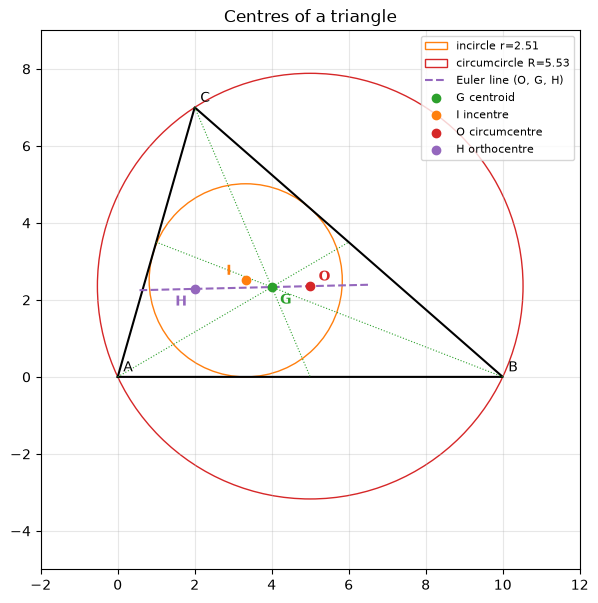

HG / GO = 2.0000   (should be 2)
Distances from O to vertices: 5.5278, 5.5278, 5.5278


In [8]:
A, B, C = np.array([0., 0.]), np.array([10., 0.]), np.array([2., 7.])
G, I, O, H = centres(A, B, C)
a, b, c = side_lengths(A, B, C)
r, R = heron(a, b, c) / ((a + b + c) / 2), dist(O, A)

fig, ax = plt.subplots(figsize=(7, 7))
draw_triangle(ax, A, B, C, color="black")
mid = {"BC": (B + C) / 2, "CA": (C + A) / 2, "AB": (A + B) / 2}
for V, M in [(A, mid["BC"]), (B, mid["CA"]), (C, mid["AB"])]:
    ax.plot(*zip(V, M), color="C2", lw=0.8, ls=":")          # medians
ax.add_patch(plt.Circle(I, r, fill=False, color="C1", label=f"incircle r={r:.2f}"))
ax.add_patch(plt.Circle(O, R, fill=False, color="C3", label=f"circumcircle R={R:.2f}"))
t = np.linspace(-0.5, 1.5, 2)
euler = O[None, :] + t[:, None] * (H - O)[None, :]
ax.plot(euler[:, 0], euler[:, 1], color="C4", ls="--", label="Euler line (O, G, H)")
for P, name, desc, col, off in [(G, "G", "centroid", "C2", (6, -12)), (I, "I", "incentre", "C1", (-14, 4)),
                                (O, "O", "circumcentre", "C3", (6, 4)), (H, "H", "orthocentre", "C4", (-14, -12))]:
    ax.scatter(*P, color=col, zorder=3, label=f"{name} {desc}")
    ax.annotate(name, P, textcoords="offset points", xytext=off, color=col, fontweight="bold")
ax.set_xlim(-2, 12); ax.set_ylim(-5, 9); ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Centres of a triangle")
plt.show()

print(f"HG / GO = {dist(H, G) / dist(G, O):.4f}   (should be 2)")
print(f"Distances from O to vertices: {dist(O, A):.4f}, {dist(O, B):.4f}, {dist(O, C):.4f}")

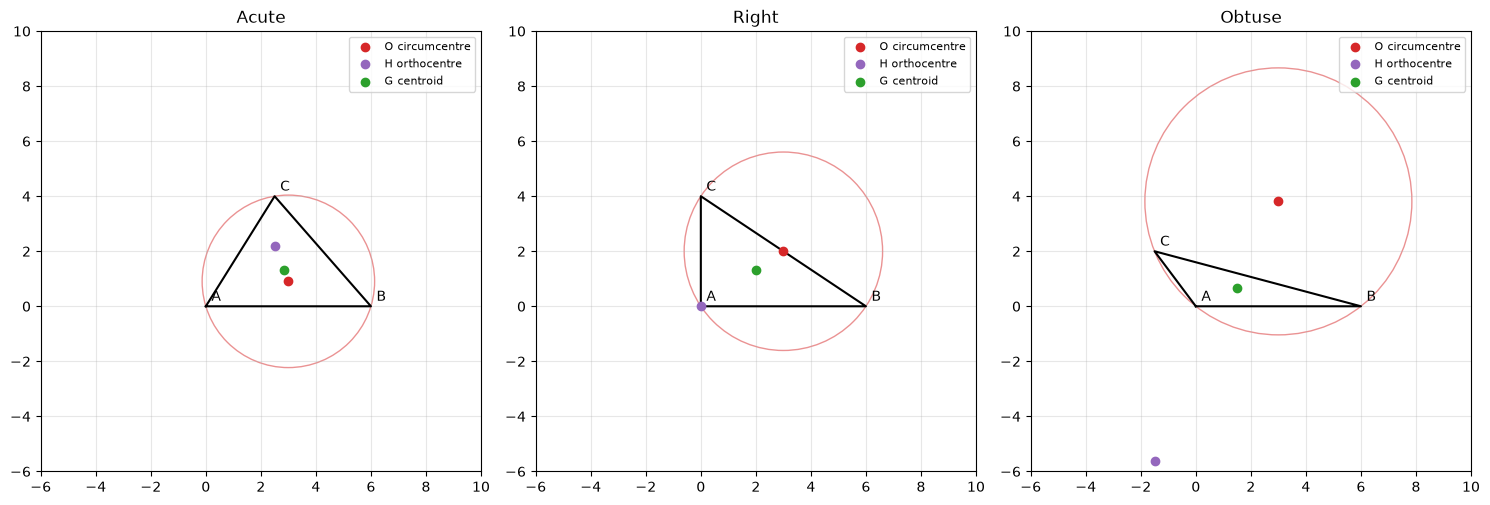

In [9]:
# Where do the circumcentre and orthocentre lie for acute / right / obtuse triangles?
cases = [("Acute", (0, 0), (6, 0), (2.5, 4)),
         ("Right", (0, 0), (6, 0), (0, 4)),
         ("Obtuse", (0, 0), (6, 0), (-1.5, 2))]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, A, B, C) in zip(axes, cases):
    G, I, O, H = centres(A, B, C)
    draw_triangle(ax, A, B, C, color="black")
    ax.add_patch(plt.Circle(O, dist(O, A), fill=False, color="C3", alpha=0.5))
    ax.scatter(*O, color="C3", label="O circumcentre", zorder=3)
    ax.scatter(*H, color="C4", label="H orthocentre", zorder=3)
    ax.scatter(*G, color="C2", label="G centroid", zorder=3)
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)
    ax.set_xlim(-6, 10); ax.set_ylim(-6, 10)
plt.tight_layout(); plt.show()

## 14. Important Theorems

### Angle Bisector Theorem
The bisector of $\angle A$ meets $BC$ at $D$. Then
$$\boxed{\frac{BD}{DC} = \frac{AB}{AC} = \frac{c}{b}}$$
so $BD = \dfrac{ac}{b + c}$ and $DC = \dfrac{ab}{b + c}$.

**Example.** $AB = 6$, $AC = 9$, $BC = 10$: $BD = \frac{10 \cdot 6}{15} = 4$, $DC = 6$.

### Apollonius' Theorem (median length)
If $AD$ is the median to $BC$ ($BD = DC = \tfrac{a}{2}$):
$$\boxed{AB^2 + AC^2 = 2\left(AD^2 + BD^2\right)}$$

**Example.** $AB = 7$, $AC = 9$, $BC = 8$: $49 + 81 = 2(AD^2 + 16) \Rightarrow AD^2 = 49 \Rightarrow AD = 7$.

### Sine Rule
$$\boxed{\frac{a}{\sin A} = \frac{b}{\sin B} = \frac{c}{\sin C} = 2R}$$
Use it when you know **two angles and a side**, or **two sides and a non-included angle**.

**Example.** $\angle A = 30^\circ$, $a = 5$: $2R = \frac{5}{\sin 30^\circ} = 10$, so $R = 5$.

### Cosine Rule
$$\boxed{a^2 = b^2 + c^2 - 2bc\cos A}$$
(and similarly for $b^2$, $c^2$). Use it when you know **three sides** or **two sides and the included angle**. When $A = 90^\circ$ it reduces to Pythagoras.

$$\cos A = \frac{b^2 + c^2 - a^2}{2bc}$$

**Example.** $b = 5$, $c = 8$, $\angle A = 60^\circ$: $a^2 = 25 + 64 - 2 \cdot 5 \cdot 8 \cdot \tfrac{1}{2} = 49 \Rightarrow a = 7$.

### Which rule to use?

| Known | Use |
|-------|-----|
| SSS | Cosine rule (for angles), Heron (for area) |
| SAS | Cosine rule (for the third side), $\tfrac{1}{2}ab\sin C$ (for area) |
| ASA / AAS | Angle sum, then sine rule |
| SSA | Sine rule — check for 0, 1 or 2 possible triangles |

## 15. Triangles in Coordinate Geometry

For vertices $A(x_1, y_1)$, $B(x_2, y_2)$, $C(x_3, y_3)$:

| Quantity | Formula |
|----------|---------|
| Side length | $AB = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$ |
| Midpoint of $AB$ | $\left(\dfrac{x_1 + x_2}{2}, \dfrac{y_1 + y_2}{2}\right)$ |
| Area | $\dfrac{1}{2}\lvert x_1(y_2 - y_3) + x_2(y_3 - y_1) + x_3(y_1 - y_2)\rvert$ |
| Collinear points | Area $= 0$ |
| Centroid | $G = \left(\dfrac{x_1 + x_2 + x_3}{3}, \dfrac{y_1 + y_2 + y_3}{3}\right)$ |
| Incentre | $I = \left(\dfrac{a x_1 + b x_2 + c x_3}{a + b + c}, \dfrac{a y_1 + b y_2 + c y_3}{a + b + c}\right)$ |
| Circumcentre | Point equidistant from $A, B, C$ (solve $OA = OB = OC$) |
| Orthocentre | Intersection of two altitudes; or $H = 3G - 2O$ |

**Example.** $A(0, 0)$, $B(4, 0)$, $C(0, 3)$ (right angle at $A$):
- $a = BC = 5$, $b = CA = 3$, $c = AB = 4$; Area $= 6$, $s = 6$
- Centroid $G = \left(\tfrac{4}{3}, 1\right)$
- Incentre $I = \left(\dfrac{5 \cdot 0 + 3 \cdot 4 + 4 \cdot 0}{12}, \dfrac{5 \cdot 0 + 3 \cdot 0 + 4 \cdot 3}{12}\right) = (1, 1)$, $r = \tfrac{6}{6} = 1$
- Circumcentre $O = (2, 1.5)$ (midpoint of hypotenuse), $R = 2.5$
- Orthocentre $H = (0, 0)$ (the right-angle vertex)

In [10]:
A, B, C = (0, 0), (4, 0), (0, 3)
G, I, O, H = centres(A, B, C)
print("Area     :", shoelace(A, B, C))
print("Centroid :", G.round(4))
print("Incentre :", I.round(4))
print("Circumctr:", O.round(4), " R =", dist(O, A))
print("Orthoctr :", H.round(4))

Area     : 6.0
Centroid : [1.3333 1.    ]
Incentre : [1. 1.]
Circumctr: [2.  1.5]  R = 2.5
Orthoctr : [0. 0.]


## 16. Common Mistakes

| Mistake | Correct idea |
|---------|-------------|
| Using SSA or AAA to prove congruence | Neither is a valid criterion (except RHS for right triangles) |
| Writing congruent/similar triangles in the wrong vertex order | $\triangle ABC \cong \triangle PQR$ means $A \leftrightarrow P$, etc. — match the order |
| Area ratio = side ratio for similar triangles | Area ratio = **square** of side ratio |
| Using Pythagoras in a non-right triangle | Use the cosine rule |
| Picking the wrong side as hypotenuse | Hypotenuse is opposite the $90^\circ$ angle (the longest side) |
| Classifying acute/obtuse without using the **longest** side as $c$ | Compare $a^2 + b^2$ with the square of the longest side |
| Triangle inequality with $\geq$ | It is strict: $a + b > c$ (equality gives a straight line) |
| Thinking the altitude always lies inside | In obtuse triangles two altitudes fall outside |
| Confusing incentre (equidistant from **sides**) with circumcentre (equidistant from **vertices**) | |
| Forgetting $s$ is the **semi**-perimeter in Heron's formula | $s = \tfrac{a + b + c}{2}$ |

## 17. Formula Sheet

| Item | Formula |
|------|---------|
| Angle sum | $\angle A + \angle B + \angle C = 180^\circ$ |
| Exterior angle | $= $ sum of interior opposite angles |
| Triangle inequality | $\lvert b - c\rvert < a < b + c$ |
| Pythagoras | $a^2 + b^2 = c^2$ |
| Acute / obtuse test | $a^2 + b^2 \gtrless c^2$ ($c$ longest) |
| Area | $\tfrac{1}{2}bh = \tfrac{1}{2}ab\sin C = \sqrt{s(s-a)(s-b)(s-c)} = rs = \dfrac{abc}{4R}$ |
| Equilateral | $h = \tfrac{\sqrt{3}}{2}a$, Area $= \tfrac{\sqrt{3}}{4}a^2$, $R = 2r = \tfrac{a}{\sqrt{3}}$ |
| Similar triangles | sides ratio $k$ ⇒ area ratio $k^2$ |
| BPT | $DE \parallel BC \Rightarrow \dfrac{AD}{DB} = \dfrac{AE}{EC}$ |
| Midpoint theorem | $DE \parallel BC$, $DE = \tfrac{1}{2}BC$ |
| Angle bisector | $\dfrac{BD}{DC} = \dfrac{AB}{AC}$ |
| Apollonius | $AB^2 + AC^2 = 2(AD^2 + BD^2)$ |
| Median length | $m_a = \tfrac{1}{2}\sqrt{2b^2 + 2c^2 - a^2}$ |
| Sine rule | $\dfrac{a}{\sin A} = \dfrac{b}{\sin B} = \dfrac{c}{\sin C} = 2R$ |
| Cosine rule | $a^2 = b^2 + c^2 - 2bc\cos A$ |
| Inradius / circumradius | $r = \dfrac{\text{Area}}{s}$, $R = \dfrac{abc}{4\,\text{Area}}$ |
| Right triangle | $R = \tfrac{c}{2}$, $r = \tfrac{a + b - c}{2}$, altitude to hypotenuse $= \tfrac{ab}{c}$ |
| Centroid | $\left(\tfrac{x_1 + x_2 + x_3}{3}, \tfrac{y_1 + y_2 + y_3}{3}\right)$, divides medians $2:1$ |
| Euler line | $O, G, H$ collinear, $HG = 2\,GO$ |

## 18. Practice Problems (with Answers)

### Level 1 — Basics
1. The angles of a triangle are in the ratio $2 : 3 : 4$. Find them.
2. An exterior angle of a triangle is $110^\circ$ and one interior opposite angle is $45^\circ$. Find the other interior opposite angle.
3. Can 4 cm, 5 cm and 10 cm be the sides of a triangle?
4. Two sides of a triangle are 5 and 9. What values can the third side take?
5. Classify the triangle with sides 7, 8, 12.
6. Find the height and area of an equilateral triangle of side 6.

### Level 2 — Standard
7. Find the area of a triangle with sides 13, 14, 15.
8. A right triangle has legs 9 and 12. Find the hypotenuse, circumradius and inradius.
9. In $\triangle ABC$, $DE \parallel BC$, $AD = 3$, $DB = 2$, $AE = 4.5$. Find $EC$.
10. Two similar triangles have corresponding sides in the ratio $3 : 5$. Find the ratio of their areas.
11. A 6 m pole casts a 4 m shadow when a tower casts a 28 m shadow. Find the tower's height.
12. In a 30°–60°–90° triangle the hypotenuse is 10. Find the other two sides.

### Level 3 — Challenge
13. In $\triangle ABC$, $AB = 7$, $AC = 9$, $BC = 8$. Find the median $AD$.
14. In $\triangle ABC$, $AB = 6$, $AC = 9$, $BC = 10$. The bisector of $\angle A$ meets $BC$ at $D$. Find $BD$ and $DC$.
15. In $\triangle ABC$, $b = 5$, $c = 8$, $\angle A = 60^\circ$. Find $a$.
16. In $\triangle ABC$, $\angle A = 30^\circ$ and $a = 5$. Find the circumradius.
17. For $A(0,0)$, $B(4,0)$, $C(0,3)$ find the area, centroid, incentre, circumcentre and orthocentre.
18. In $\triangle ABC$, $\angle A = 70^\circ$. Find $\angle BIC$, where $I$ is the incentre.

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $40^\circ, 60^\circ, 80^\circ$
2. $65^\circ$
3. No — $4 + 5 = 9 < 10$
4. $4 < x < 14$
5. $49 + 64 = 113 < 144$ → obtuse, scalene
6. Height $3\sqrt{3} \approx 5.20$, area $9\sqrt{3} \approx 15.59$
7. $s = 21$, area $= \sqrt{21 \cdot 8 \cdot 7 \cdot 6} = 84$
8. Hypotenuse 15, $R = 7.5$, $r = 3$
9. $EC = 3$
10. $9 : 25$
11. 42 m
12. 5 and $5\sqrt{3} \approx 8.66$
13. $AD = 7$
14. $BD = 4$, $DC = 6$
15. $a = 7$
16. $R = 5$
17. Area 6, $G = (4/3, 1)$, $I = (1, 1)$, $O = (2, 1.5)$, $H = (0, 0)$
18. $\angle BIC = 90^\circ + 35^\circ = 125^\circ$

</details>

In [11]:
# Check the practice answers numerically
s3 = math.sqrt(3)
x = 180 / 9
print(" 1.", [2*x, 3*x, 4*x])
print(" 2.", 110 - 45)
print(" 3.", is_triangle(4, 5, 10))
print(" 4.", f"{9 - 5} < x < {9 + 5}")
print(" 5.", classify(7, 8, 12))
print(" 6.", round(s3 / 2 * 6, 4), round(s3 / 4 * 36, 4))
print(" 7.", heron(13, 14, 15))
hyp = math.hypot(9, 12)
print(" 8.", hyp, hyp / 2, heron(9, 12, hyp) / ((9 + 12 + hyp) / 2))
print(" 9.", 4.5 * 2 / 3)
print("10.", (3**2, 5**2))
print("11.", 6 / 4 * 28)
print("12.", round(10 * math.sin(math.radians(30)), 4), round(10 * math.cos(math.radians(30)), 4))
print("13.", 0.5 * math.sqrt(2*7**2 + 2*9**2 - 8**2))
print("14.", 10 * 6 / 15, 10 * 9 / 15)
print("15.", round(math.sqrt(25 + 64 - 2*5*8*math.cos(math.radians(60))), 4))
print("16.", round(5 / (2 * math.sin(math.radians(30))), 4))
G, I, O, H = centres((0, 0), (4, 0), (0, 3))
print("17.", shoelace((0, 0), (4, 0), (0, 3)), G.round(4), I.round(4), O.round(4), H.round(4))
print("18.", 90 + 70 / 2)

 1. [40.0, 60.0, 80.0]
 2. 65
 3. False
 4. 4 < x < 14
 5. ('scalene', 'obtuse')
 6. 5.1962 15.5885
 7. 84.0
 8. 15.0 7.5 3.0
 9. 3.0
10. (9, 25)
11. 42.0
12. 5.0 8.6603
13. 7.0
14. 4.0 6.0
15. 7.0
16. 5.0
17. 6.0 [1.3333 1.    ] [1. 1.] [2.  1.5] [0. 0.]
18. 125.0
